# **Выбор приоритета** 

Условие гласит, что команда имеет мало времени, следовательно в данном **логично случае выбрать стратегию эффективности** - получить "сильный результат" результат при минимальных трудозатратах.

Но что такое "Сильный результат"?

Для команды важно, чтобы паблик давал студентам возможность расширять кругозор и давать информацию о глобальных трендах трудового рынка. В эпоху переизбытка ИИ в медиа особенно важно сохранять качество материала и ориентироваться на замотивированную, пусть и узкую нишу студентов. 

**Почему для получения сильного результата нецелесообразно опираться на охват?**

*Ценность охвата и модель монетизации в условии не определены. Поэтому принимаю допущение, что основная миссия студенческого сообщества — качественное информирование аудитории, а не максимизация числа поверхностных контактов.*

## **Подбор ключевых метрик** 

Число качественных контактов с аудиторией наиболее прямо измеряется через число просмотров с завершенным прочтением (пользователь получил полное представление о ценности контента). 

С учетом того, что временной ресурс команды ограничен, необходимо в ключевой метрике отбора отобразить эффективность человеко-часов на единицу достигнутого результата:

Для этого возьмем метрику **число просмотров с завершенным прочтением на единицу потраченного командой времени** *(Completed views per production hour or **CVPH**)*

Количество же сохранений не гарантирует, что пользователь полностью ознакомился с материалом. Люди часто сохраняют контент рефлекторно "на потом", но могут к нему не возвращаться. Однако в качестве дополнительной метрики для оценки степени долгосрочной ценности материала подойдет **конверсия просмотра в сохранение**  ***(Save_rate)***

![SoA - Юхимец.jpg](<attachment:SoA - Юхимец.jpg>)

Таким образом, выбранным приоритетом становится эффективность, замеряемая по глубине. (Интерпретируем сильный результат через степень досмотра). Так мы сможем разработать наиболее результативную стратегию для временны возможностей команды
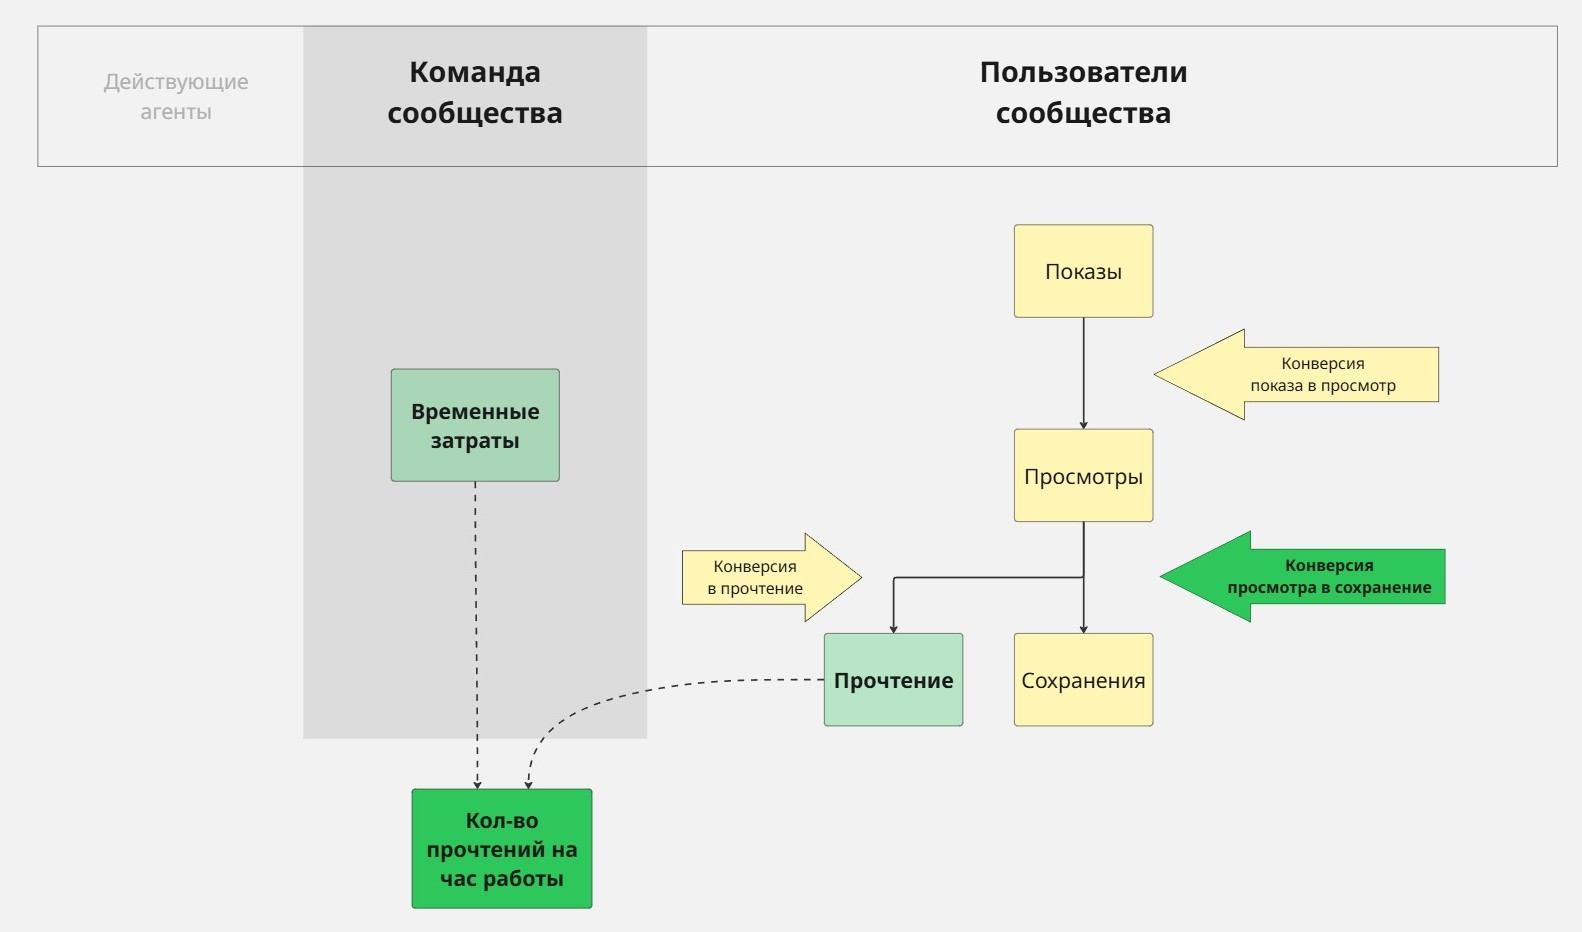

# **EDA**

## **Проверка целостности данных**

In [1]:
import pandas as pd

data = pd.read_excel('Data.xlsx', sheet_name='Данные', header=0)

display(data.head())
display(data.info())
display(data.describe(include='all'))

,publication_id,publication_date,topic,format,impressions,views,saves,completion_rate,production_hours
0,PUB-001,2026-01-05 00:00:00,Карьера,Статья,1284,298,34.0,0.811691,6.0
1,PUB-002,2026-01-05 12:00:00,Технологии,Карточки,4315,1320,108.0,0.648976,4.0
2,PUB-003,2026-01-06 00:00:00,Карьера,Статья,1466,339,37.0,0.920233,6.5
3,PUB-004,2026-01-06 12:00:00,Деньги,Карточки,1258,386,56.0,0.791510,3.0
4,PUB-005,2026-01-07 00:00:00,Технологии,Карточки,3091,817,63.0,0.717494,4.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   publication_id    91 non-null     object        
 1   publication_date  91 non-null     datetime64[ns]
 2   topic             91 non-null     object        
 3   format            91 non-null     object        
 4   impressions       91 non-null     int64         
 5   views             91 non-null     int64         
 6   saves             90 non-null     float64       
 7   completion_rate   90 non-null     float64       
 8   production_hours  91 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 6.5+ KB


None

,publication_id,publication_date,topic,format,impressions,views,saves,completion_rate,production_hours
count,91,91,91,91,91.000000,91.000000,90.000000,90.000000,91.000000
unique,90,NaN,7,3,NaN,NaN,NaN,NaN,NaN
top,PUB-042,NaN,Карьера,Статья,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,23,36,NaN,NaN,NaN,NaN,NaN
mean,NaN,2026-01-27 05:32:18.461538560,NaN,NaN,2484.527473,722.417582,55.866667,0.739763,5.818681
min,NaN,2026-01-05 00:00:00,NaN,NaN,1154.000000,264.000000,16.000000,0.511943,3.000000
25%,NaN,2026-01-16 06:00:00,NaN,NaN,1925.000000,503.500000,37.000000,0.675228,4.500000
50%,NaN,2026-01-27 00:00:00,NaN,NaN,2340.000000,669.000000,51.000000,0.725100,6.000000
75%,NaN,2026-02-07 06:00:00,NaN,NaN,3022.000000,887.500000,67.750000,0.810684,7.000000
max,NaN,2026-02-18 12:00:00,NaN,NaN,4963.000000,1868.000000,151.000000,0.940000,9.000000


### **Проверка дубликатов**

Параметры count и unique по id не совпадают -> имеются дубликаты

In [2]:
data[data.duplicated(keep=False)]

,publication_id,publication_date,topic,format,impressions,views,saves,completion_rate,production_hours
41,PUB-042,2026-01-25 12:00:00,Карьера,Статья,2340,543,58.0,0.934495,5.5
90,PUB-042,2026-01-25 12:00:00,Карьера,Статья,2340,543,58.0,0.934495,5.5


Обе строки содержат идентичную информацию - можем удалять дубликаты

In [3]:
data.drop_duplicates('publication_id', keep='first', inplace=True)

### **Однородность категориальных данных**

Проверим категориальные данные на идентичность

In [4]:
data.topic.value_counts(dropna=False)

topic
Карьера        22
Здоровье       22
Технологии     18
Город          14
Деньги         12
технологии      1
Технологии      1
Name: count, dtype: int64

Очевидно, что тема "Технологии" получила несколько вариантов названия - приведем все наименования к единому виду

In [5]:
mask = data.topic.str.strip().isin(['технологии', 'Технологии'])
data.loc[mask, 'topic'] = 'Технологии'
data.topic.value_counts(dropna=False)

topic
Карьера       22
Здоровье      22
Технологии    20
Город         14
Деньги        12
Name: count, dtype: int64

In [6]:
data.format.value_counts(dropna=False)

format
Статья            35
Карточки          32
Короткое видео    23
Name: count, dtype: int64

### **Проверка пропусков**

In [7]:
data[data.isna().any(axis=1)]

,publication_id,publication_date,topic,format,impressions,views,saves,completion_rate,production_hours
28,PUB-029,2026-01-19,Карьера,Карточки,2873,822,NaN,0.709538,3.5
74,PUB-075,2026-02-11,Город,Карточки,2781,884,56.0,NaN,5.0


Подобранные метрики являются сложными и требуют вычислений среднего после аггрегации. Наличие данных пропусков повлечет смещения в вычислениях, поэтому не следует учитывать эти публикации при расчете.

Они будут исключены непосредственно на этапе расчета метрик (каждый пропуск исключается только из расчёта затронутой метрики)


### **Проверка выбросов**

Проанализируем распределения параметров и проверим данные на выбросы

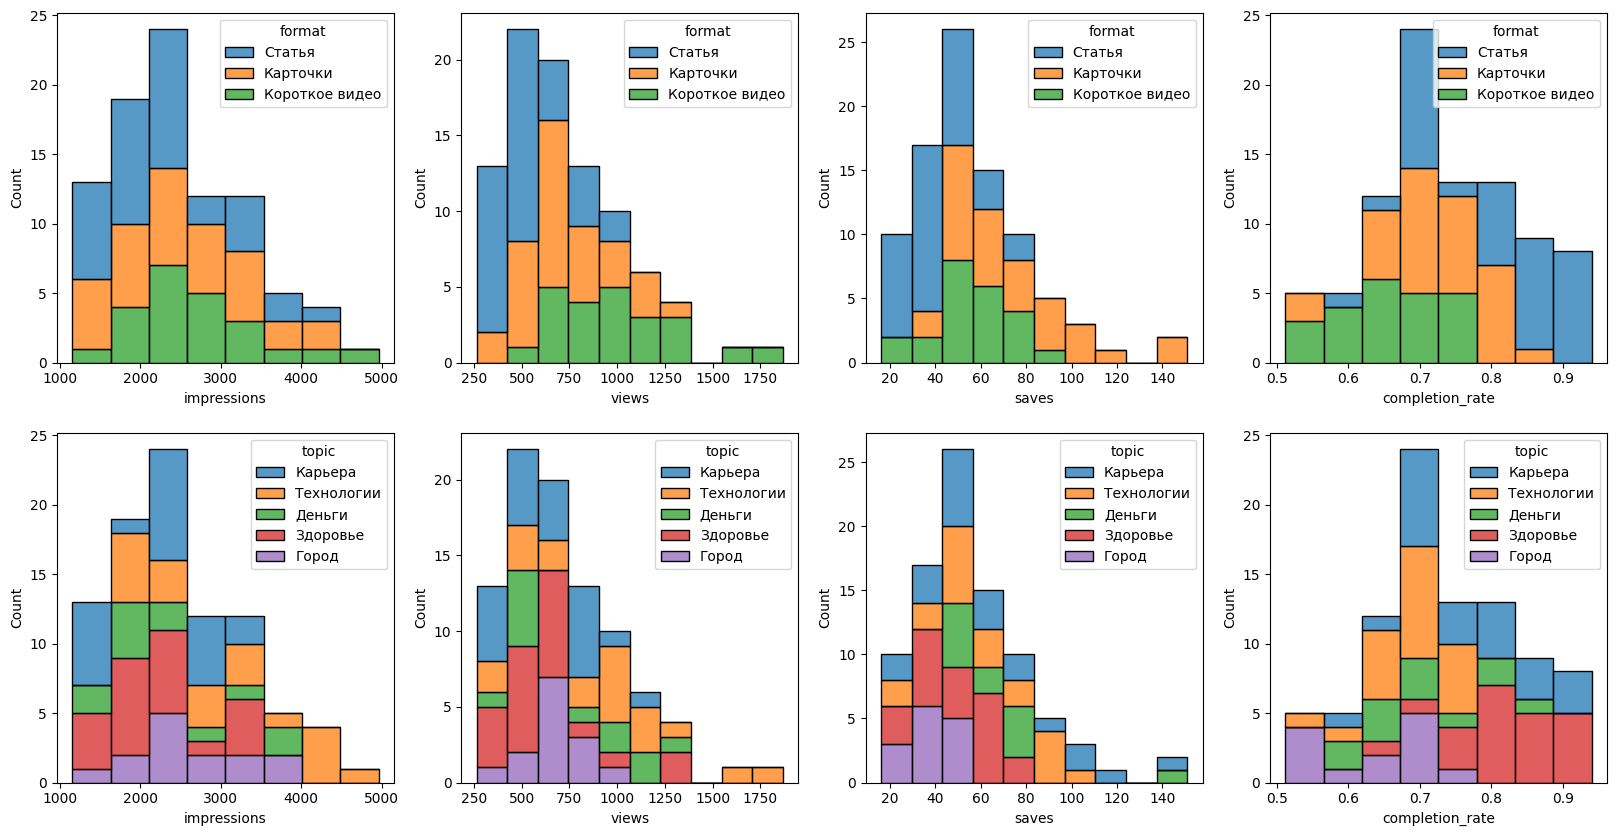

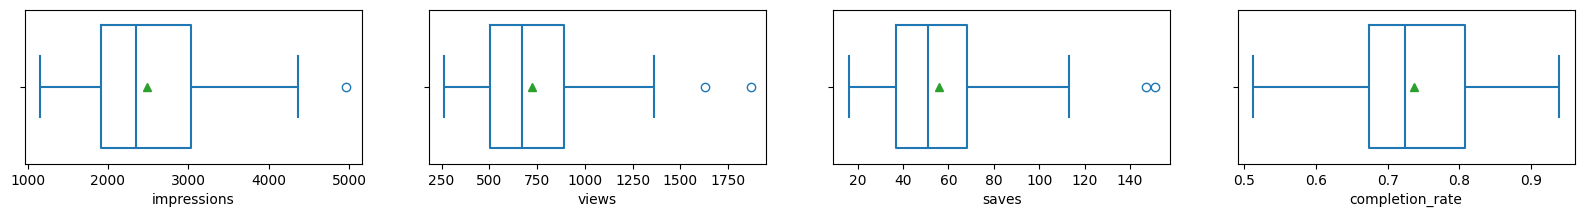

,impressions,views,saves,completion_rate
mean,2486.13,724.41,55.84,0.74
50%,2351.50,673.50,51.00,0.72


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

parameters = ['impressions', 'views', 'saves', 'completion_rate']
hues = ['format', 'topic']

rows = len(hues)
cols = len(parameters)

fig, axes = plt.subplots(rows, cols, sharex=False, sharey=False, figsize=(20, 10))

for n, ax in enumerate(axes.flatten()):
        sns.histplot(
            data=data,
            x=parameters[n % cols],
            hue=hues[n // cols],
            ax=ax,
            multiple='stack'
        )
plt.show()

fig, axes = plt.subplots(1, cols, sharex=False, sharey=False, figsize=(20, 2))

for n, ax in enumerate(axes.flatten()):
        # Выбросы определяются по 1.5 IQR по умолчанию
        sns.boxplot(
            data=data,
            x=parameters[n % cols],
            ax=ax,
            showmeans=True,
            fill=False 
        )
plt.show()

# Подсчитываем среднее и медиану для каждого параметра
display(data.describe().loc[['mean', '50%'], parameters].map('{:.2f}'.format)) 

Имеется несколько выбросовых публикаций, однако их число достаточно мало

**-> Отдельная работа с выбросами не требуется**

## **Анализ данных**

Проанализируем различные форматы взаимодействия с публикой по различным параметрам результативности

In [9]:
avg_data = data.groupby('format').agg(
    avg_impressions = ('impressions', 'mean'),
    avg_views = ('views', 'mean'),
    avg_saves = ('saves', 'mean'),
    avg_compl_rate = ('completion_rate', 'mean'),
    avg_prod_hours = ('production_hours', 'mean')
)

avg_data.map('{:.2f}'.format)

,avg_impressions,avg_views,avg_saves,avg_compl_rate,avg_prod_hours
format,,,,,
Карточки,2524.59,729.47,73.74,0.72,3.95
Короткое видео,2720.57,1001.09,55.52,0.66,8.04
Статья,2296.91,537.97,40.20,0.80,6.07


Видно, что все форматы получают схожее количество показов, значит соц.сеть не приоритизирует ни один из форматов контента и предложенная абсолютная по просмотрам метрика CVPH валидна.

### **Сравнение по CVPH**

Проведем сравнение комбинаций по ключевой метрика CVPH

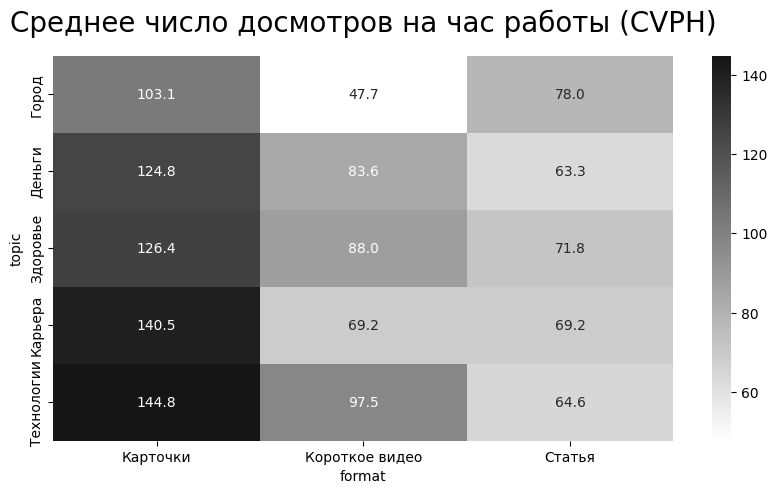

In [10]:
from matplotlib.colors import LinearSegmentedColormap

# Выделяем датафрейм без пропусков в доле полных прочтений
metric_cvph = data.dropna(subset=['views', 'completion_rate', 'production_hours']).copy()

cmap = LinearSegmentedColormap.from_list(
    "white_to_pink", ["#FFFFFF", "#151515"]
)

metric_cvph['compl_views'] = metric_cvph.views * metric_cvph.completion_rate

metric_cvph = metric_cvph.groupby(['format', 'topic']).agg(
    total_views = ('views', 'sum'),
    total_compl_views = ('compl_views', 'sum'),
    total_prod_hrs = ('production_hours', 'sum')
)

metric_cvph['cvph'] = metric_cvph.total_compl_views / metric_cvph.total_prod_hrs

result = metric_cvph

metric_cvph = metric_cvph.pivot_table(
    values='cvph',
    index='topic',
    columns='format'
)

plt.figure(figsize=(10, 5))
g = sns.heatmap(data=metric_cvph, 
                annot=True, 
                fmt='.1f',
                cmap=cmap)
g.set_title('Среднее число досмотров на час работы (CVPH)', y=1.04, size=20);

Очевидным лидерами среди комбинаций являются карточки по карьере и технологиям. 

### **Проверка эффекта накопления просмотров**

Однако стоит учитывать, что представленные в исходной таблице показатели могут иметь накопительный характер (с момента публикации и до момента выгрузки), т.к. **в условии не описано, что подсчет показатель приводится за опрделенный фиксированный период**. Подобная природа дает преимущество более старым публикациям, т.к. у них было больше времени набрать просмотров. Этот эффект сложно замерить, но стоит учитывать при формировании финальной рекомендации.

*В будущем намного корректнее было бы фиксировать накопленный показатель за фиксированный период после публикации, кратный сезонности (например, 7 дней).*

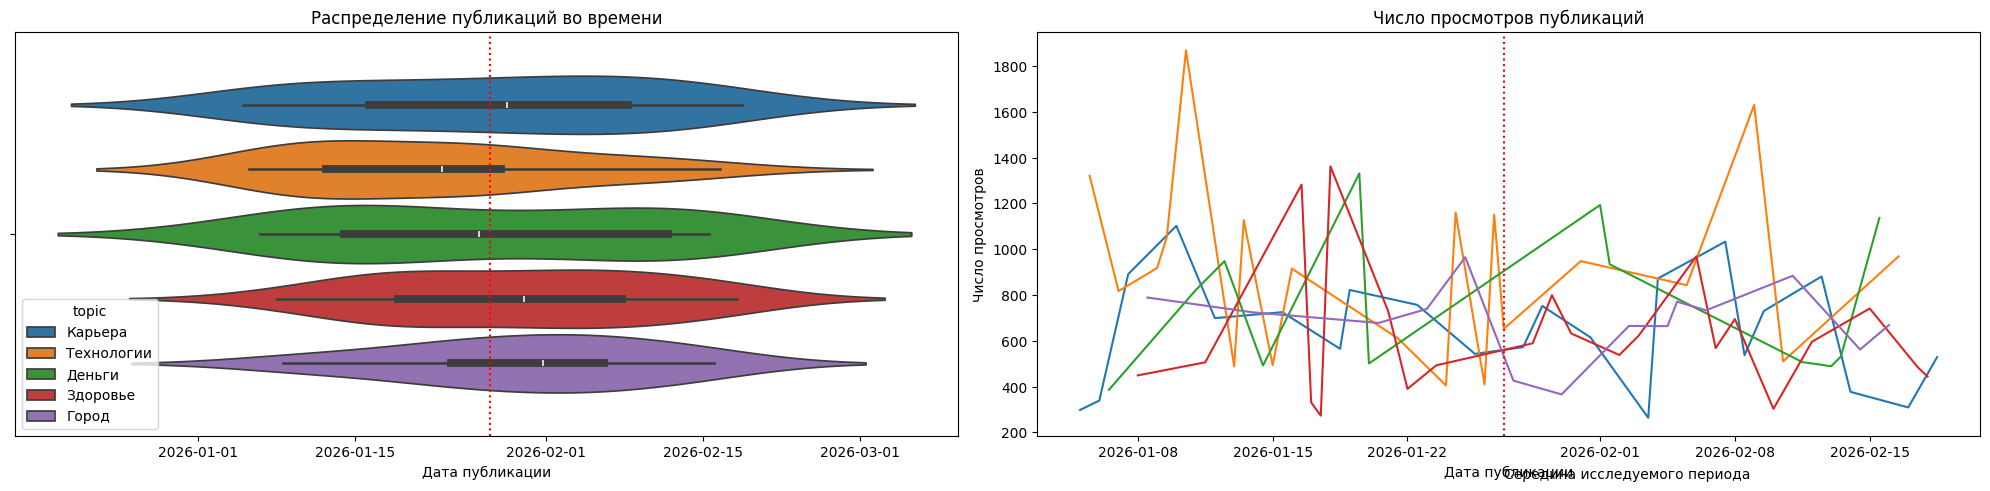

In [11]:
cutoff = data.publication_date.mean().to_period('d')

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Распределение публикаций по времени
sns.violinplot(
    data=data,
    x='publication_date',
    hue='topic',
    density_norm='width',
    gap=0.1,
    ax=axes[0]
)
axes[0].axvline(cutoff, color='r', linestyle=':')
axes[0].set_title('Распределение публикаций во времени')
axes[0].set_xlabel('Дата публикации')

# Линии накопительных досмотров
sns.lineplot(
    data=data,
    x='publication_date',
    y='views',
    hue='topic',
    ax=axes[1],
    legend=None
)

axes[1].axvline(cutoff, color='r', linestyle=':')
axes[1].text(cutoff, 0.9, 'Середина исследуемого периода')

axes[1].set_ylabel('Число просмотров')
axes[1].set_xlabel('Дата публикации')
axes[1].set_title('Число просмотров публикаций')

plt.tight_layout()
plt.show()

На графиках видно, что большая часть публикаций о технологиях приходится на начало исследуемого периода, что может сказываться на определенном приросте просмотров для старых публикаций, а следовательно и метрике CVPH. 

Проведем статистическое сравнение двух независимых групп исторических публикаций, чтобы более точно оценить статистическую значимость предполагаемого эффекта:

**H0: Среднее количество просмотров карточки в первой половине исследуемого периода (ИП) НЕ ОТЛИЧАЕТСЯ от среднего количества просмотров во второй половине ИП**

**H1: Среднее количество просмотров карточки в первой половине исследуемого периода (ИП) БОЛЬШЕ среднего количества просмотров во второй половине ИП**

Уровень значимотсти - 5%

Предполагаемый эффект распространяется на все публикации, поэтому для увеличения выборки проведем сравнение на всех публикациях

In [12]:
from scipy.stats import ttest_ind

df = data.copy()

df['dist'] = df.publication_date.apply(lambda x: 'Первая половина' if x < cutoff.to_timestamp() else 'Вторая половина')

before = df[df.dist == 'Первая половина'].views
after = df[df.dist == 'Вторая половина'].views

test_result = ttest_ind(
    before,
    after,
    equal_var=False,
    alternative='greater'
);

print(f'Количество публикаций: {len(before)} и {len(after)}')
print(f'Среднее в первой половине: {before.mean():.1f}')
print(f'Среднее во второй половине: {after.mean():.1f}')
print(f'Разница: {before.mean() - after.mean():.1f}')
print(f'Относительная разница: {(before.mean() / after.mean() - 1):.1%}')
print(f't-статистика: {test_result.statistic:.2f}')
print(f'p-value: {test_result.pvalue:.3f}')

Количество публикаций: 44 и 46
Среднее в первой половине: 765.1
Среднее во второй половине: 685.5
Разница: 79.6
Относительная разница: 11.6%
t-статистика: 1.22
p-value: 0.113


Публикации первой половины периода получили в среднем на 11.6% больше просмотров, чем публикации второй половины. На размере исходной выборки одностронний тест Уэлча (p-value = 0.113) не отвергает нулевую гипотезу на уровне значимости 5% Сравнение ранних и поздних публикаций не выявило статистически значимого различия по просмотрам, но не исключает накопительного эффекта

При формировании рекомендации **не будем учитывать эффект накопления** просмотров у более старых рекомендаций

### **Проверка по конверсии в сохренение**

С учетом этого разница между ними по основной метрике незначительна, поэтому стоит обратиться к дополнительной метрике Save_rate, чтобы получить более полную картину

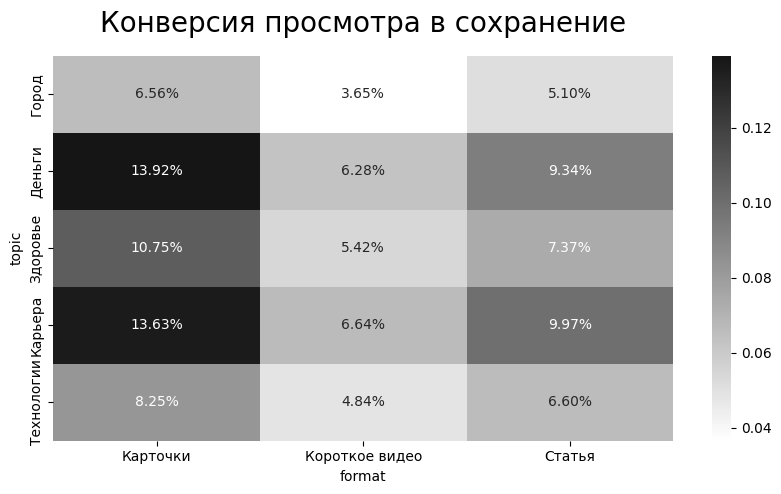

In [13]:
# Выделяем датафрейм без пропусков в сохранениях
metric_sr = data.dropna(subset=['views', 'saves']).copy()

metric_sr = metric_sr.groupby(['format', 'topic']).agg(
    total_views = ('views', 'sum'),
    total_saves = ('saves', 'sum')
)

metric_sr['save_rate'] = metric_sr.total_saves / metric_sr.total_views

metric_sr = metric_sr.pivot_table(
    values='save_rate',
    index='topic',
    columns='format'
)

plt.figure(figsize=(10, 5))
g = sns.heatmap(data=metric_sr, 
                annot=True, 
                fmt='.2%',
                cmap=cmap)
g.set_title('Конверсия просмотра в сохранение', y=1.04, size=20);

Конверсия в сохранения показывает, что из лидирующих комбинацией значительно большей долгосрочной ценностью для пользователей обладает именно карточный контент о карьере.

Это можно объяснить тем, что технологии несут в себе образовательную информацию и предполагают единоразовое прочтение. Тема карьеры имеет более практическое применение: памятки, ссылки на хакатоны и советы перед собеседованиями - весь этот материал часто пригождается после прочтения в моменты усиленной подготовки к поиску работы.

# **Вывод**

По итогу проведенного анализа я рекомендую студенческому сообществу сделать упор на **карточные публикации о карьере**, т.к. при немного меньшей эффективности на час работы (по сравнению с карточками о технологиях) мы создаем контент с более высокой долгосрочной ценностью
